In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc

In [3]:
#specfem_datapath='../specfem3d_examples/homo_3d_topo/OUTPUT_FILES/'
specfem_datapath='./OUTPUT_FILES/'


In [5]:
traceZ = pd.read_csv(specfem_datapath + "AA.S0096.BXZ.semv", 
                     header=None, 
                     sep="\s+",  # This allows multiple spaces/tabs
                     engine="python")


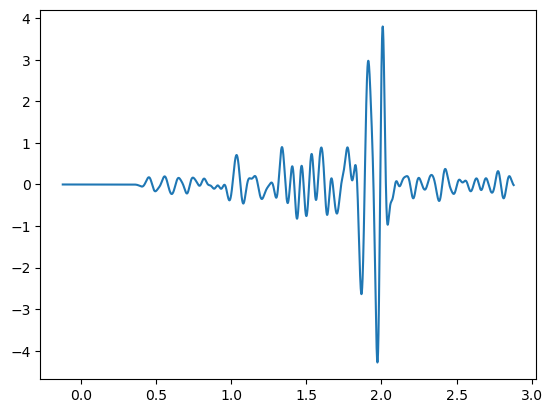

In [6]:
#traceZ = pd.read_csv(specfem_datapath+"CE.RX1500Y1000.FXZ.semv", header = None, skipinitialspace=True, delimiter=" ") 
plt.plot(traceZ[0],traceZ[1])

In [7]:
time=traceZ[0]

(18750, 3)


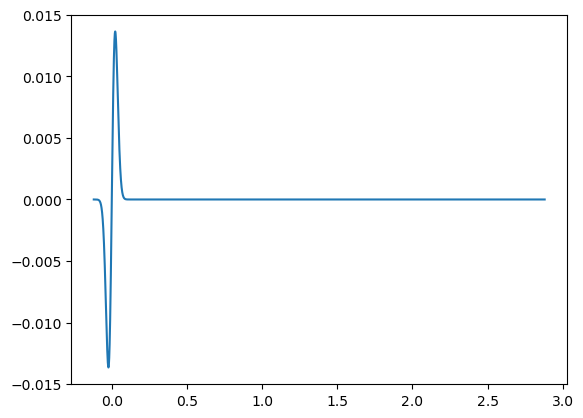

In [8]:
source =  np.loadtxt(specfem_datapath + "plot_source_time_function.txt", comments="#")
print(source.shape)
plt.plot(source[:,0],source[:,2])
t = source[:,0]

In [10]:
rec_x = range(1,402)
y=1100

k=0
dataX=np.zeros(shape=(np.size(time),np.size(rec_x)))
dataY=np.zeros(shape=(np.size(time),np.size(rec_x)))
dataZ=np.zeros(shape=(np.size(time),np.size(rec_x)))
for x in rec_x:
    filenameZ = specfem_datapath+'AA.S'+f"{x:04d}"+'.BXZ.semv'
    filenameX = specfem_datapath+'AA.S'+f"{x:04d}"+'.BXX.semv'
    traceX = pd.read_csv(filenameX, header=None, sep=r"\s+", engine="python")
    traceZ = pd.read_csv(filenameZ, header=None, sep=r"\s+", engine="python")
    dataX[:,k] = traceX[1].to_numpy()
    dataZ[:,k] = traceZ[1].to_numpy()
    k+=1
print(np.shape(dataZ))

(18750, 401)


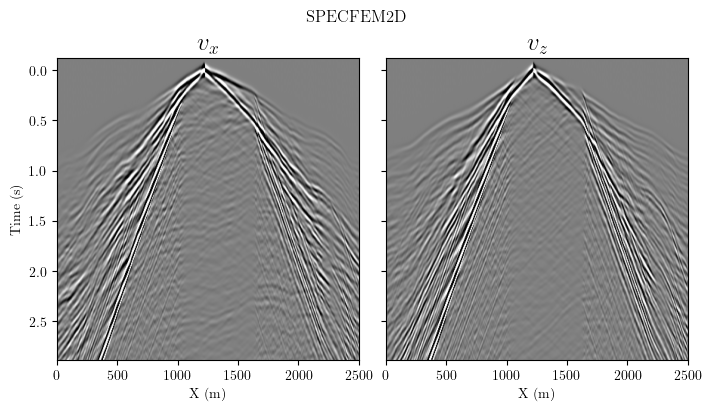

In [11]:
plt.rcParams['figure.figsize'] = [7, 4]
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)
pc=0.8
t = traceZ[0].to_numpy()
xmin=0
xmax=2500
fig1, (ax1, ax2) = plt.subplots(1, 2, layout='constrained', sharey=True)
fig1.suptitle('SPECFEM2D', fontsize=12)
ax1.set_title('$v_x$', fontsize=18)
ax1.imshow(-dataX, cmap='gray', vmin=-pc, vmax=pc, origin='upper', aspect='auto',
           extent=[xmin, xmax, t[-1], t[0]])
ax1.set_ylabel('Time (s)')
ax1.set_xlabel('X (m)')
ax2.set_title('$v_z$', fontsize=18)
ax2.imshow(dataZ, cmap='gray', vmin=-pc, vmax=pc, origin='upper', aspect='auto',
           extent=[xmin, xmax, t[-1], t[0]])
ax2.set_xlabel('X (m)')



if 0:
    fig1.savefig('shot_specfem2d.pdf',bbox_inches='tight')

In [12]:
# save data to file
dt = time[1]-time[0]
np.savez('data_specfem_seam.npz', vx=dataX, vz=dataZ, dt=dt)